# Inventory Demand Forecasting using Multiple Algorithms in Sklearn

### 1. Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Importing Dataset

In [5]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/29-Inventory%20Demand%20Forecasting/train.csv

--2026-03-19 05:48:37--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/29-Inventory%20Demand%20Forecasting/train.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17333449 (17M) [text/plain]
Saving to: ‘train.csv.1’

train.csv.1         100%[===================>]  16.53M  78.9MB/s    in 0.2s    

2026-03-19 05:48:37 (78.9 MB/s) - ‘train.csv.1’ saved [17333449/17333449]



In [6]:
df = pd.read_csv('train.csv')
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [7]:
df.tail()

,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


### 3. Data Preprocessing

1. Exploratory Data Analysis

In [8]:
df.shape

(913000, 4)

In [9]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [11]:
df.isnull().sum()

,0
date,0
store,0
item,0
sales,0


2. Feature Engineering

In [12]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [13]:
splited = df['date'].str.split('-', expand=True)
df['year'] = splited[0].astype(int)
df['month'] = splited[1].astype(int)
df['day'] = splited[2].astype(int)
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


In [14]:
from datetime import datetime

def weekend_or_weekday(year, month, day):
    date = datetime(year=year, month=month, day=day)
    return 1 if date.weekday() > 4 else 0

df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)

In [15]:
df.head()

,date,store,item,sales,year,month,day,weekend
0,2013-01-01,1,1,13,2013,1,1,0
1,2013-01-02,1,1,11,2013,1,2,0
2,2013-01-03,1,1,14,2013,1,3,0
3,2013-01-04,1,1,13,2013,1,4,0
4,2013-01-05,1,1,10,2013,1,5,1


In [16]:
from datetime import date
import holidays

kazakhstan_holidays = holidays.country_holidays('KZ')
df['holidays'] = df['date'].apply(lambda x: 1 if kazakhstan_holidays.get(x) else 0)
df.head()

,date,store,item,sales,year,month,day,weekend,holidays
0,2013-01-01,1,1,13,2013,1,1,0,1
1,2013-01-02,1,1,11,2013,1,2,0,1
2,2013-01-03,1,1,14,2013,1,3,0,0
3,2013-01-04,1,1,13,2013,1,4,0,0
4,2013-01-05,1,1,10,2013,1,5,1,0


In [17]:
df['m1'] = np.sign(df['month'] * (2 * np.pi/12))
df['m2'] = np.cos(df['month'] * (2 * np.pi/12))
df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2
0,2013-01-01,1,1,13,2013,1,1,0,1,1.0,0.866025
1,2013-01-02,1,1,11,2013,1,2,0,1,1.0,0.866025
2,2013-01-03,1,1,14,2013,1,3,0,0,1.0,0.866025
3,2013-01-04,1,1,13,2013,1,4,0,0,1.0,0.866025
4,2013-01-05,1,1,10,2013,1,5,1,0,1.0,0.866025


In [18]:
def which_day(year, month, day):
    return datetime(year=year, month=month, day=day).weekday()

df['weekday'] = df.apply(lambda x : which_day(x['year'], x['month'], x['day']), axis=1)
df.head()

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,2013-01-01,1,1,13,2013,1,1,0,1,1.0,0.866025,1
1,2013-01-02,1,1,11,2013,1,2,0,1,1.0,0.866025,2
2,2013-01-03,1,1,14,2013,1,3,0,0,1.0,0.866025,3
3,2013-01-04,1,1,13,2013,1,4,0,0,1.0,0.866025,4
4,2013-01-05,1,1,10,2013,1,5,1,0,1.0,0.866025,5


In [19]:
df.drop('date', axis=1, inplace=True)

In [20]:
df.head()

,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,1,1,13,2013,1,1,0,1,1.0,0.866025,1
1,1,1,11,2013,1,2,0,1,1.0,0.866025,2
2,1,1,14,2013,1,3,0,0,1.0,0.866025,3
3,1,1,13,2013,1,4,0,0,1.0,0.866025,4
4,1,1,10,2013,1,5,1,0,1.0,0.866025,5


1. Continue Exploratory Data Analysis

In [21]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

In [22]:
df['weekend'] = df['weekday'].apply(lambda x: 1 if x>5 else 0)
df.head()

,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,1,1,13,2013,1,1,0,1,1.0,0.866025,1
1,1,1,11,2013,1,2,0,1,1.0,0.866025,2
2,1,1,14,2013,1,3,0,0,1.0,0.866025,3
3,1,1,13,2013,1,4,0,0,1.0,0.866025,4
4,1,1,10,2013,1,5,0,0,1.0,0.866025,5


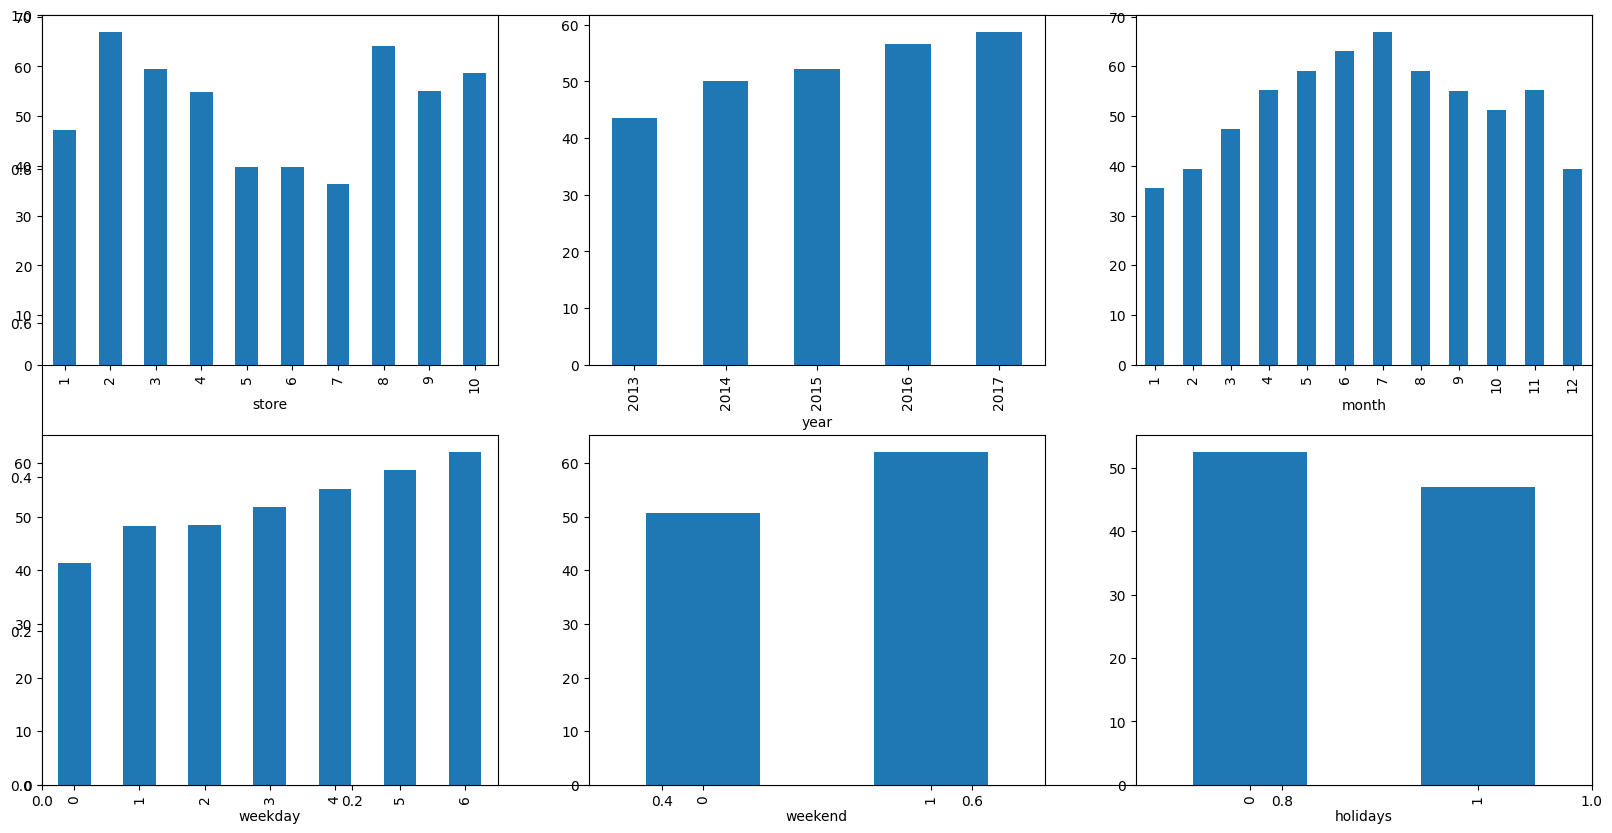

In [23]:
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    df.groupby(col)['sales'].mean().plot.bar()

plt.show()

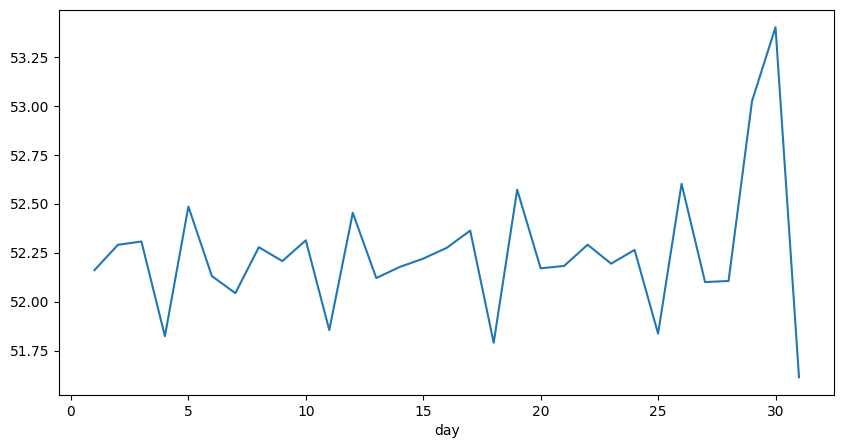

In [26]:
plt.figure(figsize=(10, 5))
df.groupby('day')['sales'].mean().plot()
plt.show()

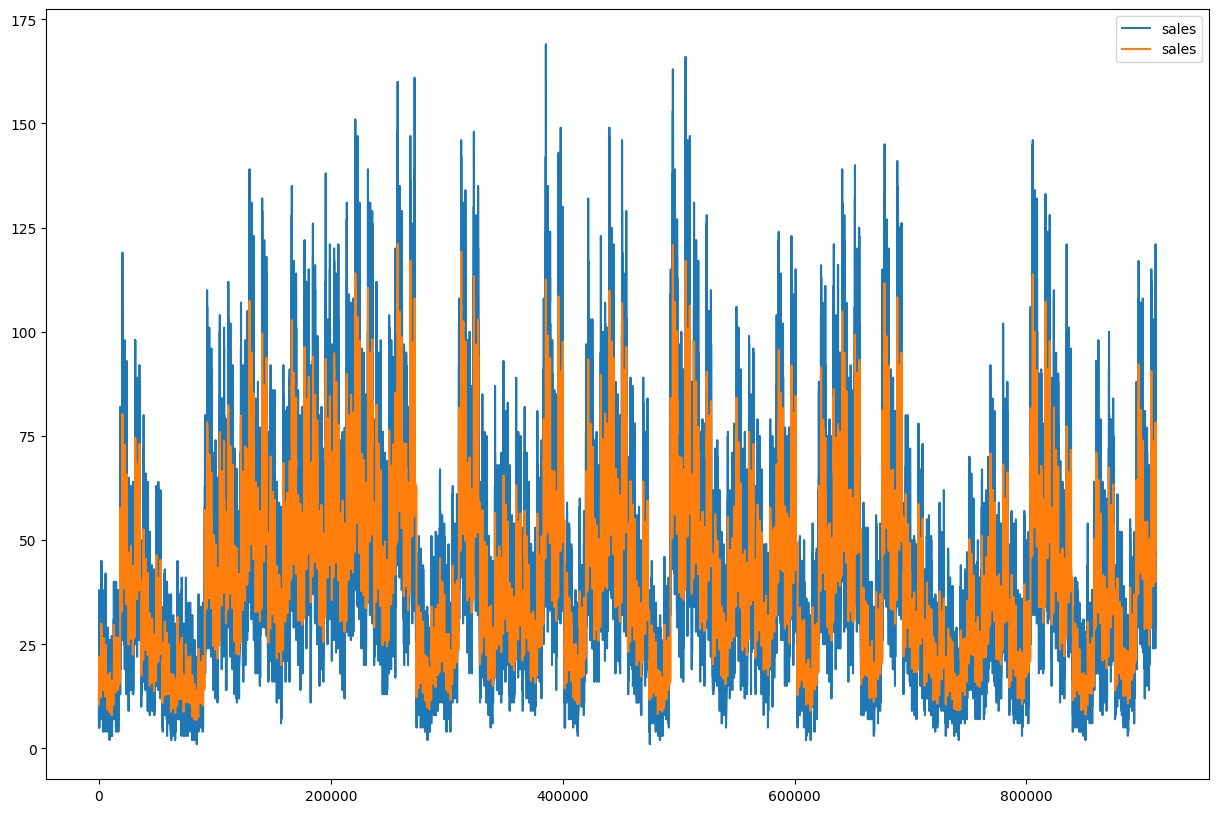

In [27]:
plt.figure(figsize=(15, 10))

# Calculating Simple Moving Average 
# for a window period of 30 days
window_size = 30
data = df[df['year']==2013]
windows = data['sales'].rolling(window_size)
sma = windows.mean()
sma = sma[window_size - 1:]

data['sales'].plot()
sma.plot()
plt.legend()
plt.show()

/tmp/ipykernel_13189/4011395090.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['sales'])


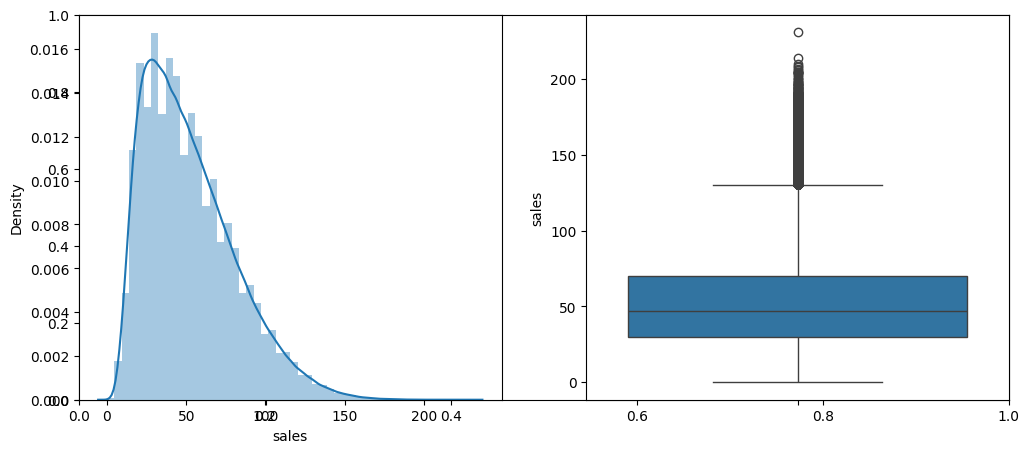

In [29]:
plt.subplots(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.distplot(df['sales'])

plt.subplot(1, 2, 2)
sns.boxplot(df['sales'])
plt.show()

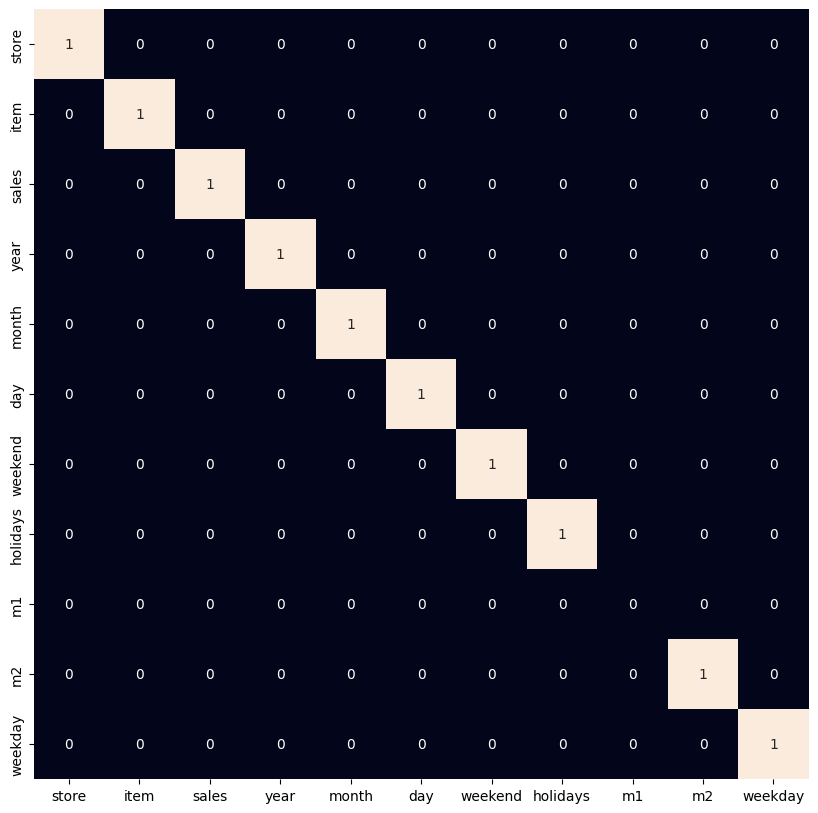

In [30]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [32]:
df = df[df['sales']<140]
df.head()

,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,1,1,13,2013,1,1,0,1,1.0,0.866025,1
1,1,1,11,2013,1,2,0,1,1.0,0.866025,2
2,1,1,14,2013,1,3,0,0,1.0,0.866025,3
3,1,1,13,2013,1,4,0,0,1.0,0.866025,4
4,1,1,10,2013,1,5,0,0,1.0,0.866025,5


In [33]:
X = df.drop(['sales', 'year'], axis=1)
y = df['sales'].values

3. Train Test Split

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

4. Feature Scalling

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [36]:
X_train.shape, X_test.shape

((725196, 9), (181299, 9))

In [37]:
y_train.shape, y_test.shape

((725196,), (181299,))

### 4. Build and Train Model

In [38]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()]

for i in range(4):
    models[i].fit(X_train, y_train)

    print(f'{models[i]} : ')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(y_train, train_preds))

    val_preds = models[i].predict(X_test)
    print('Validation Error : ', mae(y_test, val_preds))
    print()

LinearRegression() : 
Training Error :  20.920335861322393
Validation Error :  20.955898136268704

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Error :  7.019742965698242
Validation Error :  7.047334671020508

Lasso() : 
Training Error :  21.028617518901136
Validation Error :  21.06

### 5. Make Prediction

In [39]:
# Make predictions on the test set using all trained models
predictions = {}

for model in models:
    model_name = model.__class__.__name__
    predictions[model_name] = model.predict(X_test)

# Preview predictions from each model
pred_df = pd.DataFrame({'Actual': y_test})
for model_name, preds in predictions.items():
    pred_df[model_name] = preds

pred_df.head()

,Actual,LinearRegression,XGBRegressor,Lasso,Ridge
0,110,69.559010,108.476898,65.544672,69.558974
1,56,49.048491,49.025959,50.345571,49.048492
2,47,43.812513,35.789036,45.975509,43.812526
3,43,67.007813,38.175598,65.285540,67.007774
4,29,56.283438,27.296383,54.416832,56.283434


### 6. Evaluate the Models

In [41]:
# Evaluate all models on test data
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

eval_rows = []
for model_name, preds in predictions.items():
    eval_rows.append({
        'Model': model_name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })

results = pd.DataFrame(eval_rows).sort_values(by='MAE').reset_index(drop=True)
display(results)

,Model,MAE,RMSE,R2
0,XGBRegressor,7.047335,9.207945,0.889272
1,LinearRegression,20.955898,25.704679,0.137112
2,Ridge,20.955898,25.704679,0.137112
3,Lasso,21.065514,25.798039,0.130832


/tmp/ipykernel_13189/2562751385.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='MAE', ax=axes[0], palette='Blues_d')
/tmp/ipykernel_13189/2562751385.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='RMSE', ax=axes[1], palette='Greens_d')
/tmp/ipykernel_13189/2562751385.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='R2', ax=axes[2], palette='Oranges_d')


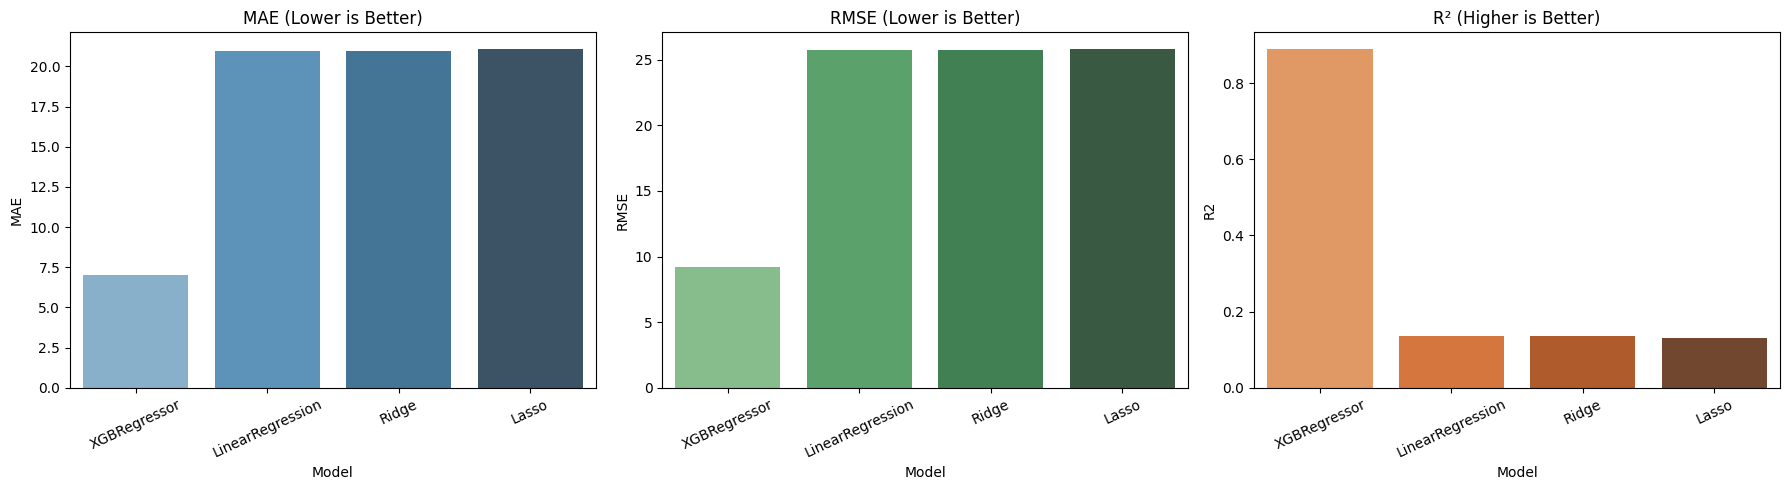

In [42]:
# Plot evaluation results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results, x='Model', y='MAE', ax=axes[0], palette='Blues_d')
axes[0].set_title('MAE (Lower is Better)')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=results, x='Model', y='RMSE', ax=axes[1], palette='Greens_d')
axes[1].set_title('RMSE (Lower is Better)')
axes[1].tick_params(axis='x', rotation=25)

sns.barplot(data=results, x='Model', y='R2', ax=axes[2], palette='Oranges_d')
axes[2].set_title('R² (Higher is Better)')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()